In [1]:
# imports necesarios
import pandas as pd 
import os

In [2]:
# definimos el directorio de trabajo
path = os.chdir(r'C:\PROYECTOS _VSC\tendencias_consumo')
os.getcwd()

'C:\\PROYECTOS _VSC\\tendencias_consumo'

# Carga de Datos

In [3]:
df = pd.read_csv("ventas-totales-supermercados-2.csv")

In [4]:
df.shape

(110, 27)

In [5]:
df.head()

,indice_tiempo,ventas_precios_corrientes,ventas_precios_constantes,ventas_precios_constantes_original,ventas_precios_constantes_desestacionalizada,ventas_precios_constantes_tendencia_ciclo,ventas_totales_canal_venta,salon_ventas,canales_on_line,ventas_totales_medio_pago,...,almacen,panaderia,lacteos,carnes,verduleria_fruteria,alimentos_preparados_rotiseria,articulos_limpieza_perfumeria,indumentaria_calzado_textiles_hogar,electronicos_articulos_hogar,otros
0,2017-01-01,27858.872083,27477.307666,99.925870,103.715654,99.276415,2.785887e+07,2.759173e+07,267141.956,2.785887e+07,...,6.705475e+06,9.459063e+05,2.880656e+06,2.606193e+06,1.050314e+06,340777.38815,4.397544e+06,772371.84765,1.838507e+06,2.806660e+06
1,2017-02-01,25994.200168,25223.428860,91.729259,99.191459,99.127434,2.599420e+07,2.574918e+07,245020.769,2.599420e+07,...,6.576625e+06,9.256186e+05,2.855640e+06,2.600084e+06,1.026167e+06,328288.69508,4.053284e+06,672290.51653,1.257662e+06,2.354085e+06
2,2017-03-01,27780.006522,26334.263640,95.768998,96.329335,99.027915,2.778001e+07,2.747223e+07,307777.804,2.778001e+07,...,7.437264e+06,1.016148e+06,3.188259e+06,2.824977e+06,1.075526e+06,353335.15476,4.354198e+06,667696.66531,1.305675e+06,2.266189e+06
3,2017-04-01,29134.272221,27045.884463,98.356927,98.728702,98.985798,2.913427e+07,2.882748e+07,306792.733,2.913427e+07,...,8.211244e+06,1.132396e+06,3.257140e+06,3.006159e+06,1.037213e+06,359694.45374,4.355707e+06,838948.24575,1.535726e+06,2.146756e+06
4,2017-05-01,27969.004677,25631.863992,93.214603,98.428403,99.054456,2.796900e+07,2.756931e+07,399693.262,2.796900e+07,...,7.651058e+06,1.033082e+06,3.232636e+06,2.799142e+06,9.826512e+05,336568.00849,4.206102e+06,915895.14981,1.824462e+06,2.117971e+06


In [6]:
df.isnull().sum()

indice_tiempo                                   0
ventas_precios_corrientes                       0
ventas_precios_constantes                       0
ventas_precios_constantes_original              0
ventas_precios_constantes_desestacionalizada    0
ventas_precios_constantes_tendencia_ciclo       0
ventas_totales_canal_venta                      0
salon_ventas                                    0
canales_on_line                                 0
ventas_totales_medio_pago                       0
efectivo                                        0
tarjetas_debito                                 0
tarjetas_credito                                0
otros_medios                                    0
ventas_totales_grupo_articulos                  0
subtotal_ventas_alimentos_bebidas               0
bebidas                                         0
almacen                                         0
panaderia                                       0
lacteos                                         0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 27 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   indice_tiempo                                 110 non-null    object 
 1   ventas_precios_corrientes                     110 non-null    float64
 2   ventas_precios_constantes                     110 non-null    float64
 3   ventas_precios_constantes_original            110 non-null    float64
 4   ventas_precios_constantes_desestacionalizada  110 non-null    float64
 5   ventas_precios_constantes_tendencia_ciclo     110 non-null    float64
 6   ventas_totales_canal_venta                    110 non-null    float64
 7   salon_ventas                                  110 non-null    float64
 8   canales_on_line                               110 non-null    float64
 9   ventas_totales_medio_pago                     110 non-null    flo

In [8]:
# Se convierte el tipo de dato de objetc a datetime
df['indice_tiempo'] = pd.to_datetime(df['indice_tiempo'])

In [9]:
df['indice_tiempo'].dtype

dtype('<M8[ns]')

## Filtramos las columnas de interés

In [10]:
columnas_interes = ['indice_tiempo','salon_ventas','canales_on_line']
df_modelo = df[columnas_interes]

In [11]:
df_modelo.head()

,indice_tiempo,salon_ventas,canales_on_line
0,2017-01-01,2.759173e+07,267141.956
1,2017-02-01,2.574918e+07,245020.769
2,2017-03-01,2.747223e+07,307777.804
3,2017-04-01,2.882748e+07,306792.733
4,2017-05-01,2.756931e+07,399693.262


# Búsqueda de anomalías

In [12]:
# Comparamos la media vs la mediana para detectar si existen valores extremos (Outliers)
resumen_estadistico = df_modelo[['salon_ventas', 'canales_on_line']].agg(['mean', 'median'])
# Mostramos el resultado
print(resumen_estadistico)

        salon_ventas  canales_on_line
mean    5.388060e+08     1.726495e+07
median  1.193835e+08     4.630234e+06


Text(0, 0.5, 'Ventas (millones)')

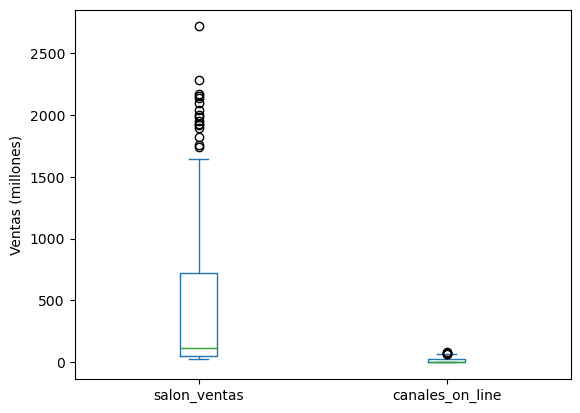

In [13]:
# Dividimos por 1_000_000 para que el gráfico muestre "Millones" y sea legible
ax = (df_modelo[['salon_ventas', 'canales_on_line']] / 1_000_000).plot.box()
ax.set_ylabel('Ventas (millones)')

salon_ventas          Axes(0.125,0.11;0.352273x0.77)
canales_on_line    Axes(0.547727,0.11;0.352273x0.77)
dtype: object

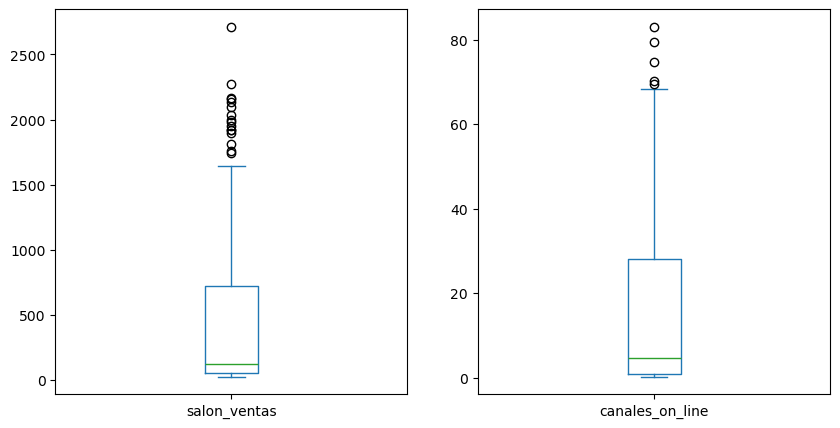

In [14]:
# Al usar subplots=True, cada canal de venta tendrá su propia escala vertical
(df_modelo[['salon_ventas', 'canales_on_line']] / 1_000_000).plot.box(subplots=True, figsize=(10, 5))

### Conclusión del Análisis de Anomalías:

Al comparar las métricas de localización (media vs. mediana) y generar los diagramas de caja, se confirma la presencia de múltiples valores atípicos superiores en ambos canales de venta (Salón y Online). Dado que la Regresión Lineal es muy sensible a valores extremos, estos registros (posiblemente causados por la inflación reciente) deberán tenerse en cuenta al momento de evaluar el rendimiento del modelo.

# Análisis de Correlación

In [15]:
# 1. Matriz de Correlación: Medida matemática (va de -1 a +1)
correlacion = df_modelo[['salon_ventas', 'canales_on_line']].corr()
print("Matriz de Correlación:")
print(correlacion)

Matriz de Correlación:
                 salon_ventas  canales_on_line
salon_ventas         1.000000         0.990782
canales_on_line      0.990782         1.000000


Text(0, 0.5, 'Ventas Online')

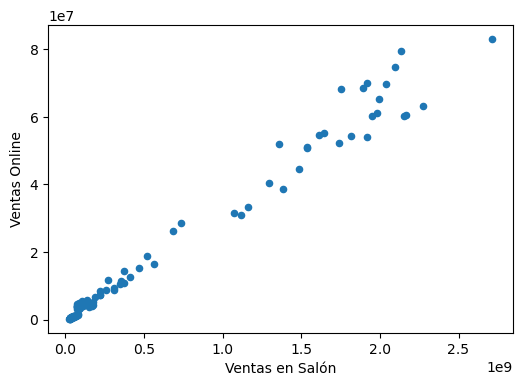

In [16]:
# 2. Diagrama de dispersión (Scatter plot): Visualización de la relación
ax = df_modelo.plot.scatter(x='salon_ventas', y='canales_on_line', figsize=(6, 4))
ax.set_xlabel('Ventas en Salón')
ax.set_ylabel('Ventas Online')

Los datos demuestran matemáticamente que cuando las ventas en el supermercado físico suben, las ventas por internet suben en una proporción casi exacta, moviéndose juntas.

# Detección de Multicolinealidad

Condición en la que hay redundancia entre las variables predictoras. Se da cuando múltiples variables "están casi perfectamente correlacionadas entre sí" y puede causar inestabilidad numérica al ajustar la ecuación de regresión.

**Solución:** Las variables deben eliminarse hasta que desaparezca la multicolinealidad.

**Conclusión:** No se realizará una Regresión Lineal Múltiple, sino que se aplicará el modelo más estable para este caso: una Regresión Lineal Simple. Se utilizará una única variable predictora fuerte (salon_ventas) para para predecir la variable de respuesta o resultado (canales_on_line).


In [26]:
# 1. Seleccionamos posibles variables predictoras de tu dataset original
columnas_predictoras = ['salon_ventas', 'efectivo', 'tarjetas_debito', 'tarjetas_credito']
df_predictores = df[columnas_predictoras]
# 2. Generamos la matriz de correlación para detectar Multicolinealidad
matriz_multicolinealidad = df_predictores.corr()

print("Matriz de Multicolinealidad entre Predictores:")
print(matriz_multicolinealidad)

Matriz de Multicolinealidad entre Predictores:
                  salon_ventas  efectivo  tarjetas_debito  tarjetas_credito
salon_ventas          1.000000  0.992966         0.995314          0.998698
efectivo              0.992966  1.000000         0.993913          0.987250
tarjetas_debito       0.995314  0.993913         1.000000          0.991112
tarjetas_credito      0.998698  0.987250         0.991112          1.000000


## Decisión metodológica

Para resolver el problema del impacto inflacionario y la presencia de valores atípicos (outliers) en los meses recientes, se toma la decisión de no predecir valores monetarios nominales. En su lugar, se calculará el porcentaje de ventas online sobre el total de ventas. Al trabajar con proporciones, el sesgo de la inflación se cancela matemáticamente, lo que estabilizará la Regresión Lineal sin necesidad de eliminar datos históricos válidos.

In [19]:
# Creamos una copia limpia para nuestro modelo definitivo
df_final = df_modelo.copy()

In [20]:
# Calculamos las ventas totales del mes
ventas_totales = df_final['salon_ventas'] + df_final['canales_on_line']

In [27]:
# Creamos la nueva variable: Porcentaje de ventas online
df_final['porcentaje_online'] = (df_final['canales_on_line'] / ventas_totales) * 100


In [29]:
# Creamos la columna numérica (1, 2, 3...)
df_final['mes_numero'] = range(1, len(df_final) + 1)

In [30]:
# Visualizamos las primeras filas para confirmar
df_final.head()

,indice_tiempo,salon_ventas,canales_on_line,porcentaje_online,mes_numero
0,2017-01-01,2.759173e+07,267141.956,0.958912,1
1,2017-02-01,2.574918e+07,245020.769,0.942598,2
2,2017-03-01,2.747223e+07,307777.804,1.107911,3
3,2017-04-01,2.882748e+07,306792.733,1.053030,4
4,2017-05-01,2.756931e+07,399693.262,1.429058,5


In [31]:
# Visualizamos las últimas filas 
df_final.tail()

,indice_tiempo,salon_ventas,canales_on_line,porcentaje_online,mes_numero
105,2025-10-01,2.096199e+09,7.476753e+07,3.443974,106
106,2025-11-01,2.132007e+09,7.931497e+07,3.586766,107
107,2025-12-01,2.713065e+09,8.304578e+07,2.970047,108
108,2026-01-01,2.276136e+09,6.309728e+07,2.697349,109
109,2026-02-01,2.154052e+09,6.008939e+07,2.713891,110


# Regresión Lineal Simple

### Uso del 100% de los datos en Regresión Lineal

Se entrena el modelo con todas las observaciones disponibles, sin dividir el dataset en entrenamiento y prueba. Dado que la Regresión Lineal Simple presenta bajo riesgo de sobreajuste, se priorizó aprovechar toda la información histórica para estimar la tendencia global de la manera más precisa posible y brindar una referencia sólida para la toma de decisiones.

### Limitación Geográfica

Los datos están agregados a nivel nacional y no incluyen información de ubicación. Por ello, el modelo estima una tendencia promedio para toda Argentina. Esta simplificación puede ocultar diferencias regionales, ya que la adopción de canales online suele variar entre zonas urbanas y rurales.

In [36]:
# Importamos el modelo de Regresión Lineal
from sklearn.linear_model import LinearRegression

# 1. Definimos el predictor (X) y el resultado que queremos predecir (y)
X = df_final[['mes_numero']]  # Debe mantenerse como DataFrame
y = df_final['porcentaje_online']

# 2. Inicializamos y entrenamos el modelo con el 100% de los datos
modelo = LinearRegression()
modelo.fit(X, y)

# 3. Extraemos los parámetros de la recta ajustada
print(f'Intersección (b0): {modelo.intercept_:.3f}')
print(f'Pendiente (b1): {modelo.coef_[0]:.3f}')

# 4. Mostramos la ecuación del modelo
print(f'Ecuación: y = {modelo.intercept_:.3f} + {modelo.coef_[0]:.3f}x')

Intersección (b0): 1.637
Pendiente (b1): 0.020
Ecuación: y = 1.637 + 0.020x


### Interpretación de los Coeficientes

**Intersección (b₀ = 1.637):** Representa el valor estimado del porcentaje de ventas online cuando `mes_numero = 0`. En términos prácticos, indica que al inicio del período analizado la participación del canal online era aproximadamente del **1.637%** de las ventas totales.

**Pendiente (b₁ = 0.020):** Es el crecimiento promedio mensual del porcentaje de ventas online. Esto significa que la participación del canal digital aumenta, en promedio, **0.020 puntos porcentuales por mes**, evidenciando una tendencia sostenida de expansión del comercio electrónico a lo largo del tiempo.

### Predicción
**Si la tendencia se mantiene, ¿qué porcentaje de nuestra logística debe estar dedicada a envíos online para el cierre de año, en Diciembre de 2026**

Desde enero de 2017 hasta el último dato de febrero de 2026 hay exactamente 110 meses. Por lo tanto, marzo de 2026 será el mes 111... y diciembre de 2026 será el mes 120.
Aplicamos la ecuación: y=1.637+(0.020×120) y=1.637+2.400 y=4.037

De acuerdo con la tendencia histórica de los últimos 9 años, se estima que para diciembre de 2026, aproximadamente el 4.04% del volumen total de ventas provendrá del canal online.